In [89]:
# Code cell
# importing the necessary packages
import os
import sys
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn import preprocessing, model_selection

# Chooses GPU if available; otherwise CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)


Device: cuda


In [90]:
#my path 
data_dir = Path("./ml-latest-small")

if not data_dir.exists():
    raise FileNotFoundError(f"{data_dir} not found")

ratings_path = data_dir / "ratings.csv"
print("Ratings file:", ratings_path)
df = pd.read_csv(ratings_path)
print("Rows:", len(df))
df.head()

Ratings file: ml-latest-small\ratings.csv
Rows: 100836


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Users: 610
Movies: 9724
Ratings distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


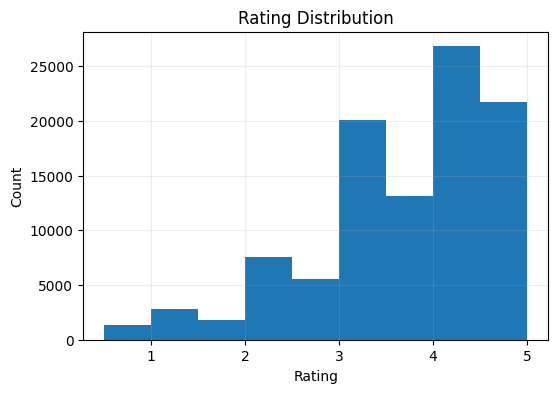

In [91]:
# Code cell
print("Users:", df.userId.nunique())
print("Movies:", df.movieId.nunique())
print("Ratings distribution:")
print(df.rating.value_counts().sort_index())

plt.figure(figsize=(6,4))
plt.hist(df.rating, bins=np.arange(0.5, 5.5, 0.5))
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.grid(alpha=0.2)
plt.show()


In [92]:
# Code cell
class MovieLensDataset(Dataset):
    def __init__(self, users, movies, ratings):
        self.users = users
        self.movies = movies
        self.ratings = ratings

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return {
            "users": torch.tensor(self.users[idx], dtype=torch.long),
            "movies": torch.tensor(self.movies[idx], dtype=torch.long),
            "ratings": torch.tensor(self.ratings[idx], dtype=torch.float32),
        }


In [93]:
# Code cell
class RecommendationModel(nn.Module):
    def __init__(self, num_users, num_movies, feature_dimension =128, hidden_dim=256, dropout_rate=0.1):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, feature_dimension )
        self.movie_emb = nn.Embedding(num_movies, feature_dimension )
        self.fc1 = nn.Linear(2 * feature_dimension , hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

        # init embeddings 
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.movie_emb.weight, std=0.01)

    def forward(self, users, movies):
        u = self.user_emb(users)
        m = self.movie_emb(movies)
        x = torch.cat([u, m], dim=1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        out = self.fc2(x)
        return out.squeeze(1)  # shape (batch,)


In [94]:
# Label encode user and movie ids to 0..N-1
lbl_user = preprocessing.LabelEncoder()
lbl_movie = preprocessing.LabelEncoder()
df['user_enc'] = lbl_user.fit_transform(df.userId.values)
df['movie_enc'] = lbl_movie.fit_transform(df.movieId.values)

# train-val split stratified on rating
df_train, df_val = model_selection.train_test_split(
    df, test_size=0.1, random_state=SEED, stratify=df.rating.values
)

print("Train rows:", len(df_train), "Val rows:", len(df_val))

train_dataset = MovieLensDataset(
    users=df_train.user_enc.values,
    movies=df_train.movie_enc.values,
    ratings=df_train.rating.values
)
val_dataset = MovieLensDataset(
    users=df_val.user_enc.values,
    movies=df_val.movie_enc.values,
    ratings=df_val.rating.values
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

num_users = len(lbl_user.classes_)
num_movies = len(lbl_movie.classes_)
print("num_users:", num_users, "num_movies:", num_movies)


Train rows: 90752 Val rows: 10084
num_users: 610 num_movies: 9724


In [95]:
# Code cell
def train_one_run(model, train_loader, optimizer, loss_fn, device, epochs=20, log_every=100):
    model.to(device)
    model.train()
    losses = []  # list of average losses logged
    step_samples = 0
    running_loss = 0.0

    total_samples = len(train_loader.dataset)
    for epoch in range(epochs):
        step_samples = 0
        running_loss = 0.0
        for i, batch in enumerate(train_loader):
            users = batch['users'].to(device)
            movies = batch['movies'].to(device)
            ratings = batch['ratings'].to(device)

            preds = model(users, movies)
            loss = loss_fn(preds, ratings)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # accumulate
            running_loss += loss.item() * users.size(0)  # sum loss over batch
            step_samples += users.size(0)

            if step_samples >= log_every:
                avg_loss = running_loss / step_samples
                losses.append(avg_loss)
                # reset counters for next logging block
                running_loss = 0.0
                step_samples = 0

        # at end of epoch, if leftover samples not logged, log them
        if step_samples > 0:
            avg_loss = running_loss / step_samples
            losses.append(avg_loss)
            running_loss = 0.0
            step_samples = 0

    return losses




In [96]:
def evaluate_model(model, val_loader, loss_fn, device):
    model.to(device)
    model.eval()
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for batch in val_loader:
            users = batch['users'].to(device)
            movies = batch['movies'].to(device)
            ratings = batch['ratings'].to(device)
            preds = model(users, movies)
            loss = loss_fn(preds, ratings)
            total_loss += loss.item() * users.size(0)
            total_n += users.size(0)
    return total_loss / total_n

In [97]:

# Code cell
# Parameters for this run
feature_dimension  = 128        # constant n
epochs = 30
hidden_dim = 256
dropout_rate = 0.1
lr = 1e-3
log_every_samples = 100     # log average loss every these many samples

# instantiate model, optimizer, loss
model = RecommendationModel(num_users=num_users, num_movies=num_movies,
                            feature_dimension =feature_dimension , hidden_dim=hidden_dim,
                            dropout_rate=dropout_rate)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss(reduction='mean')

print("Training with Feature Dimension =", feature_dimension )
losses_const_n = train_one_run(model, train_loader, optimizer, loss_fn, device, epochs=epochs, log_every=log_every_samples)

# save for later
#np.savetxt("loss_curve_const_n.txt", np.array(losses_const_n))


Training with Feature Dimension = 128


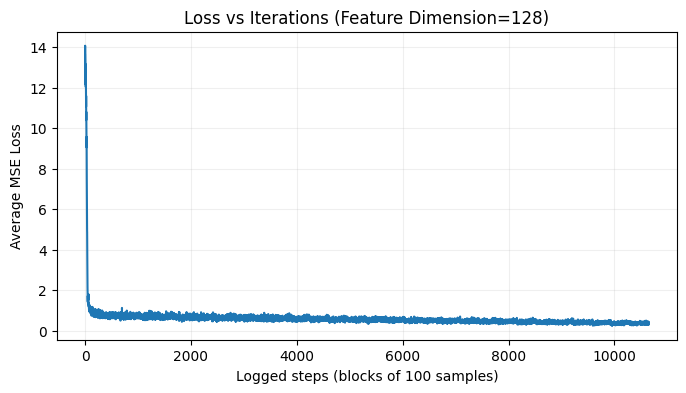

In [98]:

# plot
plt.figure(figsize=(8,4))
plt.plot(losses_const_n)
plt.title(f"Loss vs Iterations (Feature Dimension={feature_dimension })")
plt.xlabel("Logged steps (blocks of {} samples)".format(log_every_samples))
plt.ylabel("Average MSE Loss")
plt.grid(alpha=0.2)
plt.show()


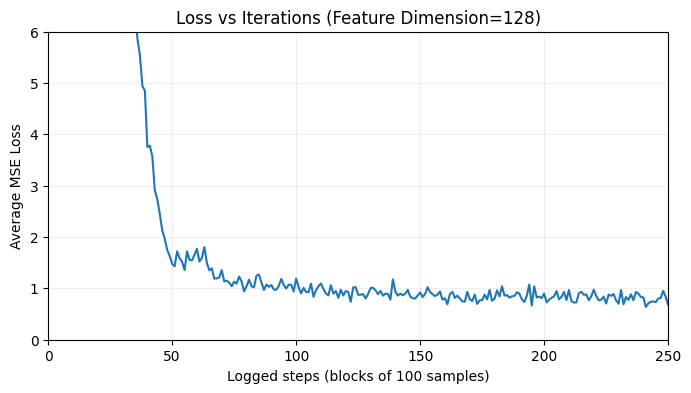

In [135]:

# plot
plt.figure(figsize=(8,4))
plt.plot(losses_const_n)
plt.title(f"Loss vs Iterations (Feature Dimension={feature_dimension })")
plt.xlabel("Logged steps (blocks of {} samples)".format(log_every_samples))
plt.ylabel("Average MSE Loss")
plt.grid(alpha=0.2)
plt.ylim(0, 6)   # <-- restrict y-axis range here
plt.xlim(0, 250) 
plt.show()

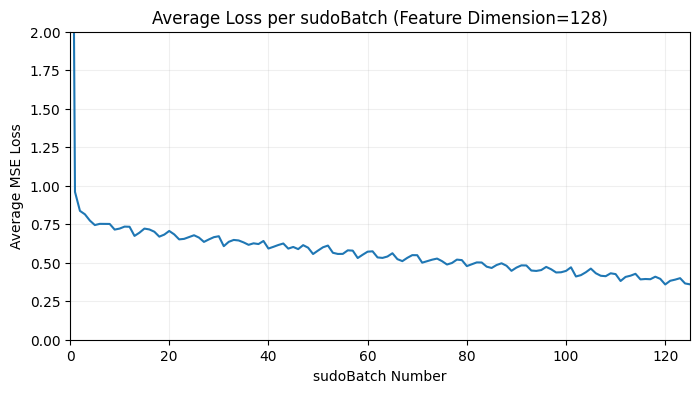

In [120]:

# Number of steps 
steps_per_batch = 80

# Convert logged losses to a numpy array
losses_arr = np.array(losses_const_n)

# Compute average loss per batch
num_batches = len(losses_arr) // steps_per_batch
avg_losses_per_batch = [losses_arr[i*steps_per_batch:(i+1)*steps_per_batch].mean() for i in range(num_batches)]

# Plot
plt.figure(figsize=(8,4))
plt.plot(avg_losses_per_batch)
plt.title(f"Average Loss per sudoBatch (Feature Dimension={feature_dimension})")
plt.xlabel("sudoBatch Number")
plt.ylabel("Average MSE Loss")
plt.grid(alpha=0.2)
plt.ylim(0, 2)   # <-- restrict y-axis range here
plt.xlim(0, 125) 
plt.show()

In [ ]:
# Code cell
emb_sizes = [32, 64, 128, 256, 512]  # 
epochs_vary = 30                     # 
lr = 1e-3
log_every_samples = 100
hidden_dim = 256
dropout_rate = 0.1
#epochs = 30


all_losses = {}
for emb in emb_sizes:
    print(f"\nTraining with Feature Dimension = {emb}")
    model_v = RecommendationModel(num_users=num_users, num_movies=num_movies,
                                  feature_dimension =emb, hidden_dim=256, dropout_rate=0.1)
    optimizer_v = torch.optim.Adam(model_v.parameters(), lr=lr)
    loss_fn = nn.MSELoss(reduction='mean')
    losses_v = train_one_run(model_v, train_loader, optimizer_v, loss_fn, device, epochs=epochs_vary, log_every=log_every_samples)
    all_losses[emb] = losses_v
  




Training with Feature Dimension = 32

Training with Feature Dimension = 64

Training with Feature Dimension = 128

Training with Feature Dimension = 256

Training with Feature Dimension = 512


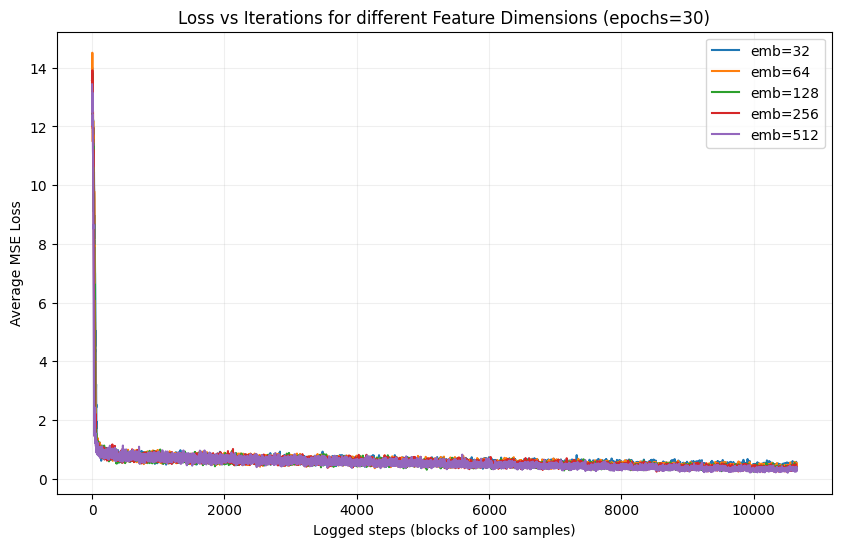

In [ ]:
# Plot all on same figure
plt.figure(figsize=(10,6))
labels = []
for emb in emb_sizes:
    losses_v = all_losses[emb]
    # To align curves, plot them as-is. They may have different lengths depending on epochs and data size.
    plt.plot(losses_v, label=f"emb={emb}")
plt.xlabel("Logged steps (blocks of {} samples)".format(log_every_samples))
plt.ylabel("Average MSE Loss")
plt.title(f"Loss vs Iterations for different Feature Dimensions (epochs={epochs_vary})")
#plt.ylim(0, 4)   # <-- restrict y-axis range here
#plt.xlim(0, 250)  
plt.legend()
plt.grid(alpha=0.2)
plt.show()

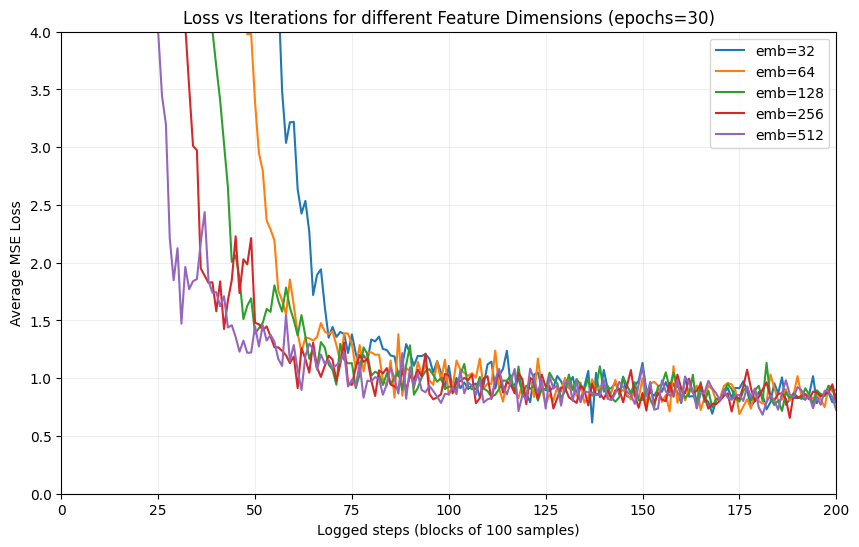

In [102]:
# Plot all on same figure
plt.figure(figsize=(10,6))
labels = []
for emb in emb_sizes:
    losses_v = all_losses[emb]
    # To align curves, plot them as-is. They may have different lengths depending on epochs and data size.
    plt.plot(losses_v, label=f"emb={emb}")
plt.xlabel("Logged steps (blocks of {} samples)".format(log_every_samples))
plt.ylabel("Average MSE Loss")
plt.title(f"Loss vs Iterations for different Feature Dimensions (epochs={epochs_vary})")
plt.ylim(0, 4)   # <-- restrict y-axis range here
plt.xlim(0, 200)  
plt.legend()
plt.grid(alpha=0.2)
plt.show()


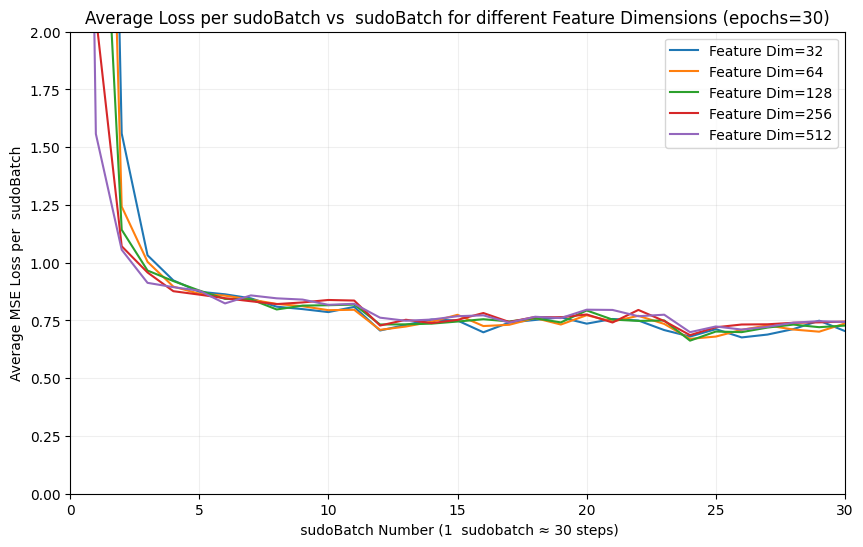

In [133]:
# Plot average loss per batch for all Feature Dimensions
steps_per_batch = 30

plt.figure(figsize=(10,6))

for emb in emb_sizes:
    losses_v = np.array(all_losses[emb])
    # compute average loss per batch
    num_batches = len(losses_v) // steps_per_batch
    avg_losses_per_batch = [losses_v[i*steps_per_batch:(i+1)*steps_per_batch].mean() for i in range(num_batches)]
    plt.plot(avg_losses_per_batch, label=f"Feature Dim={emb}")

plt.xlabel(f" sudoBatch Number (1  sudobatch ≈ {steps_per_batch} steps)")
plt.ylabel("Average MSE Loss per  sudoBatch")
plt.title(f"Average Loss per sudoBatch vs  sudoBatch for different Feature Dimensions (epochs={epochs_vary})")
plt.ylim(0, 2)
plt.xlim(0, 30)  # optional, adjust if needed
plt.legend()
plt.grid(alpha=0.2)
plt.show()


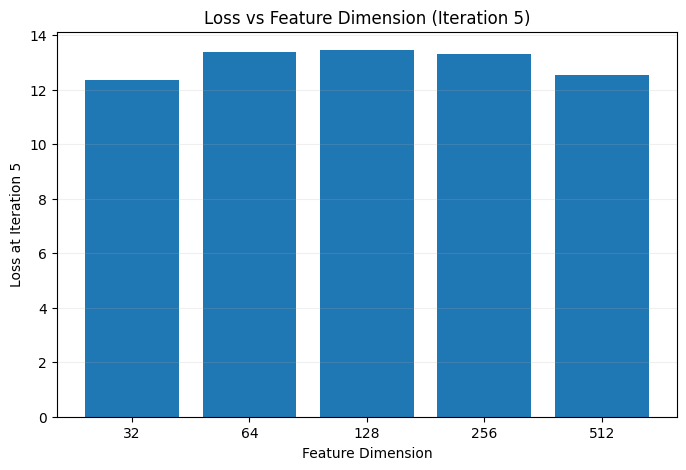

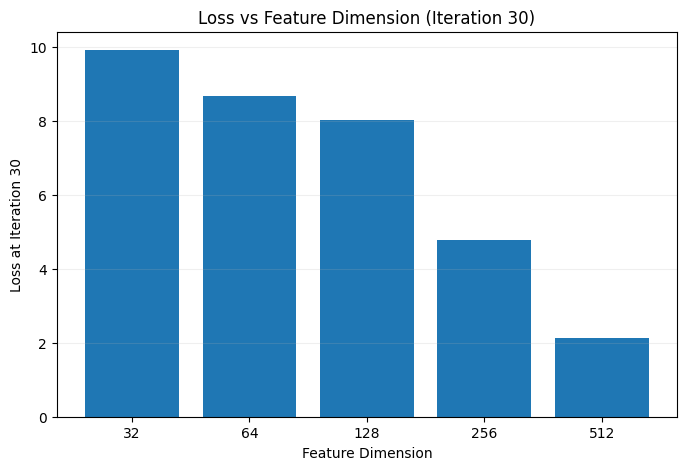

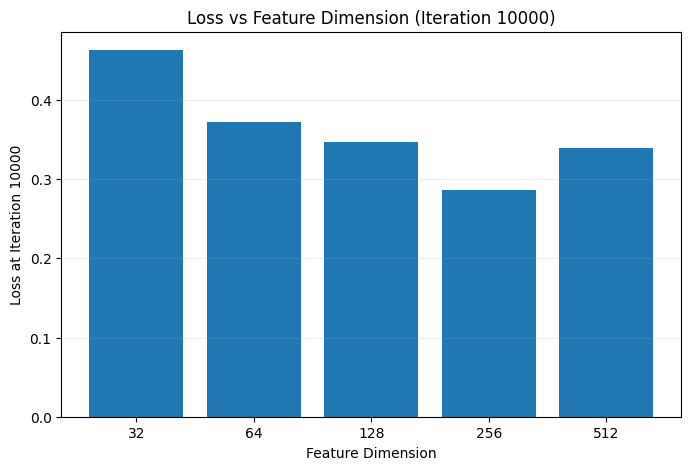

In [136]:
# Show loss vs Feature Dimension for iteration numbers (if available)
iterations = [5,30,10000]

for iteration in iterations:

    losses_at_iter = []
    embs_available = []

    for emb in emb_sizes:
        losses = all_losses[emb]
        if len(losses) > iteration:
            losses_at_iter.append(losses[iteration])
            embs_available.append(emb)

    plt.figure(figsize=(8,5))
    plt.bar([str(e) for e in embs_available], losses_at_iter)
    plt.xlabel("Feature Dimension")
    plt.ylabel(f"Loss at Iteration {iteration}")
    plt.title(f"Loss vs Feature Dimension (Iteration {iteration})")
    plt.grid(axis='y', alpha=0.2)
    plt.show()

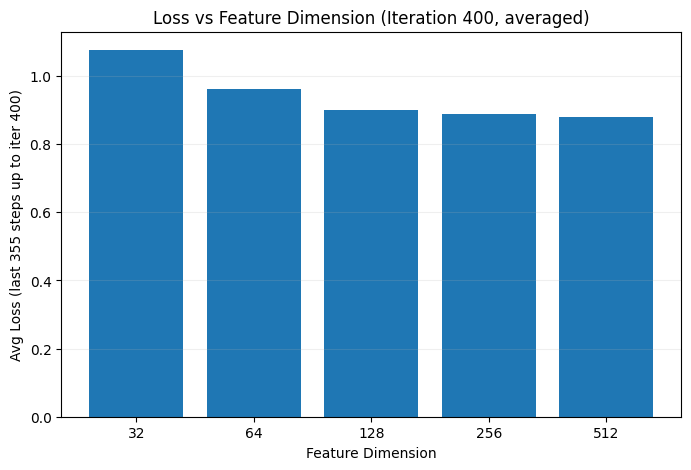

In [148]:
# Show averaged loss vs Feature Dimension for selected iteration numbers
iterations = [400]
window = 355   # average over last 50 points up to iteration

for iteration in iterations:
    losses_at_iter = []
    embs_available = []

    for emb in emb_sizes:
        losses = all_losses[emb]
        if len(losses) > iteration:
            # Define averaging window (avoid going below 0)
            start_idx = max(0, iteration - window)
            avg_loss = np.mean(losses[start_idx:iteration+1])
            losses_at_iter.append(avg_loss)
            embs_available.append(emb)

    plt.figure(figsize=(8,5))
    plt.bar([str(e) for e in embs_available], losses_at_iter)
    plt.xlabel("Feature Dimension")
    plt.ylabel(f"Avg Loss (last {window} steps up to iter {iteration})")
    plt.title(f"Loss vs Feature Dimension (Iteration {iteration}, averaged)")
    plt.grid(axis='y', alpha=0.2)
    plt.show()


In [105]:

num_train = len(train_loader.dataset)
num_val = len(val_loader.dataset)
batch_size = 256  # as used
logs_per_epoch = math.ceil(num_train / batch_size) if batch_size >= log_every_samples else math.ceil(num_train / log_every_samples)
print("Train samples:", num_train)
print("Val samples:", num_val)
print("Batch size:", batch_size)
print("Logs per epoch (approx):", logs_per_epoch)
print("Batches per epoch (ceil):", math.ceil(num_train / batch_size))
print("Epochs configured:", epochs)
print("Expected total logs approx:", logs_per_epoch * epochs)
print("Expected optimizer steps (batches) per epoch:", math.ceil(num_train / batch_size))
print("Expected total optimizer steps:", math.ceil(num_train / batch_size) * epochs)

Train samples: 90752
Val samples: 10084
Batch size: 256
Logs per epoch (approx): 355
Batches per epoch (ceil): 355
Epochs configured: 30
Expected total logs approx: 10650
Expected optimizer steps (batches) per epoch: 355
Expected total optimizer steps: 10650


In [152]:
def movie_rating_predict(user_id, movie_id):
    user_idx = torch.tensor([lbl_user.transform([user_id])[0]], dtype=torch.long).to(device)
    movie_idx = torch.tensor([lbl_movie.transform([movie_id])[0]], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        predicted_rating = model(user_idx, movie_idx).item()
    print(f"Predicted rating: {predicted_rating:.2f}")

movie_rating_predict(user_id=1, movie_id=100)

Predicted rating: 4.50


In [150]:
def suggest_similar_movies(user_id, top_n=5, model=model, df=df, lbl_user=lbl_user, lbl_movie=lbl_movie, device=device):
    """
    Suggest similar movies for a given user based on predicted ratings.

    Args:
        user_id (int): Original userId from the dataset.
        top_n (int): Number of movie suggestions to return.
        model: Trained recommendation model.
        df: DataFrame containing movie info.
        lbl_user: LabelEncoder for userId.
        lbl_movie: LabelEncoder for movieId.
        device: Torch device.

    Returns:
        List of (movieId, predicted_rating) tuples.
    """
    if user_id not in lbl_user.classes_:
        raise ValueError("User ID not found in dataset.")

    user_enc = lbl_user.transform([user_id])[0]
    all_movie_encs = np.arange(len(lbl_movie.classes_))
    user_tensor = torch.full((len(all_movie_encs),), user_enc, dtype=torch.long).to(device)
    movie_tensor = torch.tensor(all_movie_encs, dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(user_tensor, movie_tensor).cpu().numpy()

    # Get top N movie indices
    top_indices = np.argsort(preds)[::-1][:top_n]
    top_movie_encs = all_movie_encs[top_indices]
    top_movie_ids = lbl_movie.inverse_transform(top_movie_encs)
    top_ratings = preds[top_indices]

    return list(zip(top_movie_ids, top_ratings))


suggestions = suggest_similar_movies(user_id=1, top_n=5)
print("Suggested movies (movieId, predicted_rating):", suggestions)

Suggested movies (movieId, predicted_rating): [(4708, 5.801703), (1279, 5.7956233), (6376, 5.7764964), (26073, 5.703563), (163072, 5.698935)]
